# Task 11: OT-2 Robot Inference

Running inference with trained model: `ppo_group_1mm`

In [2]:
# Import necessary libraries
import sys
import os
from pathlib import Path
import numpy as np
from stable_baselines3 import PPO
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw, ImageFont
import imageio

In [3]:
# Set up path to simulation
datalabs_path = next((p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'simulation' / 'cloned').exists()), Path.cwd().parent)
sys.path.insert(0, str(datalabs_path))

# Add simulation/cloned to path so sim_class can be imported
sim_dir = datalabs_path / "simulation" / "cloned"
sys.path.insert(0, str(sim_dir))

# Import the simulation class
from simulation.cloned.sim_class import Simulation

# Change to the directory where sim_class.py expects to be run from
original_dir = Path.cwd()
os.chdir(sim_dir)

print(f"Changed directory to: {os.getcwd()}")
print(f"DataLabs path: {datalabs_path}")
print(f"Simulation directory: {sim_dir}")

Changed directory to: <project>\DataLabs\simulation\cloned
DataLabs path: <project>\DataLabs
Simulation directory: <project>\DataLabs\simulation\cloned


In [4]:
# Add Task 11 directory to path so we can import ot2_env
task11_dir = datalabs_path / "robot_control" / "rl"
sys.path.insert(0, str(task11_dir))

# Import Aaron's wrapper (it will import sim_class from the path we set earlier)
from ot2_env import OT2Env

print("Successfully imported OT2Env from ot2_env")

Successfully imported OT2Env from aaron_ot2_wrapper


In [5]:
# Load the trained model from Task 11 directory
model_filename = "ppo_group_1mm.zip"
model_path = task11_dir / "models" / model_filename
model = PPO.load(str(model_path))

print(f"Successfully loaded model: {model_filename}")
print(f"Model path: {model_path}")

Successfully loaded model: 251222.0540_aaron_lr3e-4_b128_s2048_th1mm.zip
Model path: <project>\DataLabs\Task 11\251222.0540_aaron_lr3e-4_b128_s2048_th1mm.zip


In [6]:
# Create environment with rendering enabled
# Using Aaron's wrapper with 1mm threshold (same as training)
env = OT2Env(render=True, max_steps=300, target_threshold=0.001)

print("Environment created successfully")
print(f"Target threshold: {env.target_threshold * 1000}mm")
print(f"Max steps: {env.max_steps}")

Environment created successfully
Target threshold: 1.0mm
Max steps: 300


In [7]:
# Run inference for multiple episodes with trajectory tracking
num_episodes = 5

# Store data for all episodes
all_trajectories = []
all_goals = []
all_distances = []

for episode in range(num_episodes):
    obs, info = env.reset()
    episode_reward = 0
    steps = 0
    
    # Track positions for this episode
    positions_x = []
    positions_y = []
    positions_z = []
    distances = []
    
    print(f"\n{'='*80}")
    print(f"EPISODE {episode + 1}/{num_episodes}")
    print(f"{'='*80}")
    print(f"Goal position: X={env.goal_position[0]:.4f}m, Y={env.goal_position[1]:.4f}m, Z={env.goal_position[2]:.4f}m")
    print(f"{'='*80}\n")
    
    done = False
    while not done:
        # Get action from trained model (deterministic for inference)
        action, _states = model.predict(obs, deterministic=True)
        
        # Execute action
        obs, reward, terminated, truncated, info = env.step(action)
        
        # Record current position and distance
        current_pos = info['current_position']
        positions_x.append(current_pos[0])
        positions_y.append(current_pos[1])
        positions_z.append(current_pos[2])
        distances.append(info['distance_to_goal'])
        
        episode_reward += reward
        steps += 1
        done = terminated or truncated
        
        # Print pipette coordinates every step for screen recording
        distance_mm = info['distance_to_goal'] * 1000
        print(f"Step {steps:3d} | Pipette Position: X={current_pos[0]:7.4f}m  Y={current_pos[1]:7.4f}m  Z={current_pos[2]:7.4f}m | Distance: {distance_mm:6.2f}mm")
    
    # Store episode data
    all_trajectories.append({
        'x': positions_x,
        'y': positions_y,
        'z': positions_z
    })
    all_goals.append(env.goal_position.copy())
    all_distances.append(distances)
    
    # Episode summary
    final_distance = info['distance_to_goal'] * 1000  # Convert to mm
    success = final_distance < 1.0  # 1mm threshold
    
    print(f"\n{'-'*80}")
    print(f"EPISODE {episode + 1} COMPLETE")
    print(f"{'-'*80}")
    print(f"  Steps taken:    {steps}")
    print(f"  Total reward:   {episode_reward:.2f}")
    print(f"  Final distance: {final_distance:.2f}mm")
    print(f"  Success:        {'YES' if success else 'NO'}")
    print(f"{'-'*80}\n")

print(f"\n{'='*80}")
print("ALL EPISODES COMPLETE")
print(f"{'='*80}")


EPISODE 1/5
Goal position: X=0.1859m, Y=-0.1639m, Z=0.2440m

Step   1 | Pipette Position: X= 0.0735m  Y= 0.0889m  Z= 0.1205m | Distance: 302.99mm
Step   2 | Pipette Position: X= 0.0744m  Y= 0.0878m  Z= 0.1224m | Distance: 300.97mm
Step   3 | Pipette Position: X= 0.0757m  Y= 0.0862m  Z= 0.1253m | Distance: 297.98mm
Step   4 | Pipette Position: X= 0.0776m  Y= 0.0839m  Z= 0.1291m | Distance: 293.85mm
Step   5 | Pipette Position: X= 0.0799m  Y= 0.0811m  Z= 0.1339m | Distance: 288.78mm
Step   6 | Pipette Position: X= 0.0826m  Y= 0.0778m  Z= 0.1410m | Distance: 282.33mm
Step   7 | Pipette Position: X= 0.0858m  Y= 0.0739m  Z= 0.1491m | Distance: 274.93mm
Step   8 | Pipette Position: X= 0.0895m  Y= 0.0694m  Z= 0.1574m | Distance: 266.89mm
Step   9 | Pipette Position: X= 0.0936m  Y= 0.0644m  Z= 0.1657m | Distance: 258.42mm
Step  10 | Pipette Position: X= 0.0982m  Y= 0.0589m  Z= 0.1741m | Distance: 249.45mm
Step  11 | Pipette Position: X= 0.1032m  Y= 0.0527m  Z= 0.1824m | Distance: 239.91mm
Ste

## Visualization of Results

Saving visualizations to: <project>\DataLabs\Task 11\results_aaron

Saved: trajectory_episode_1.png


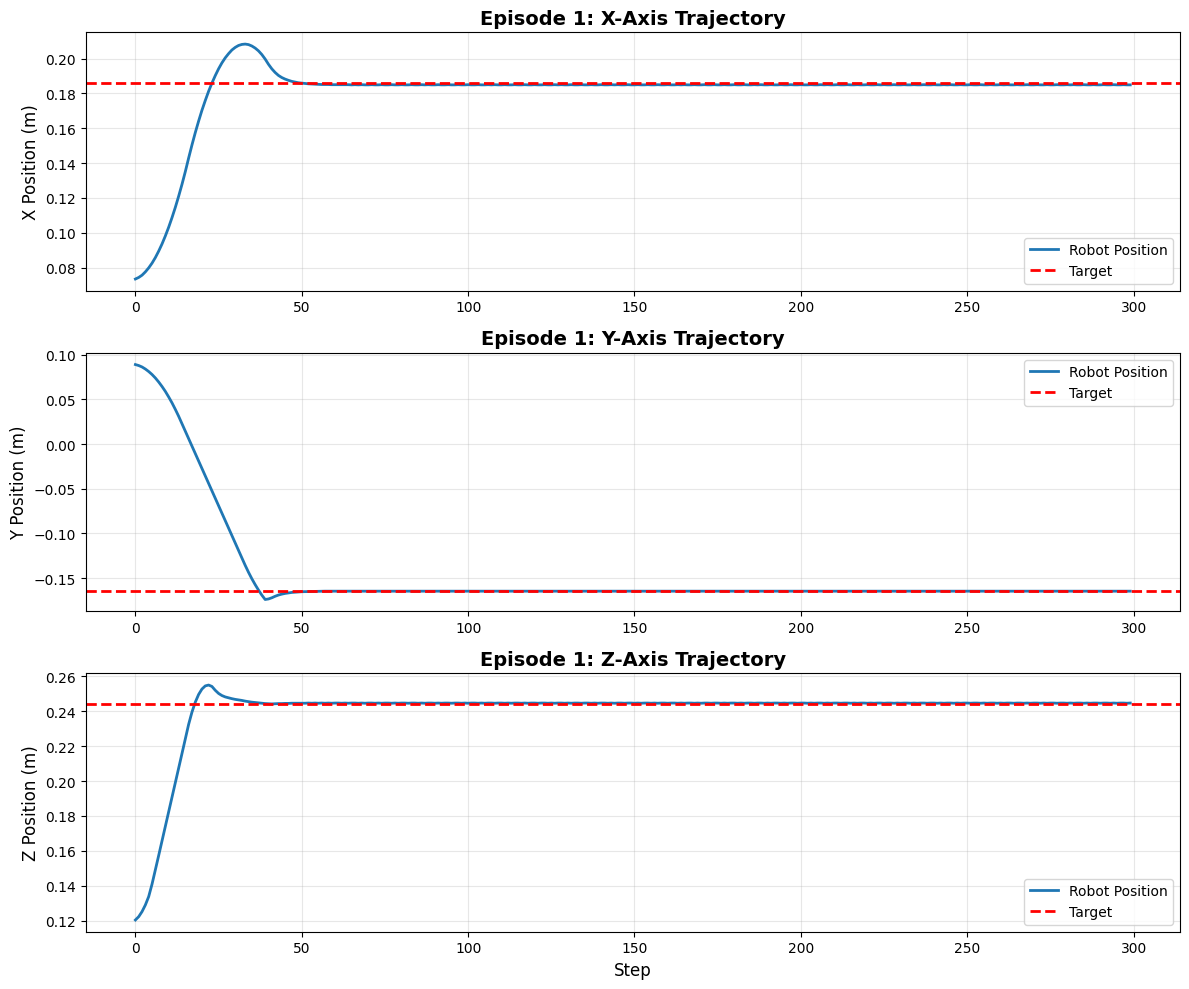

Saved: trajectory_episode_2.png


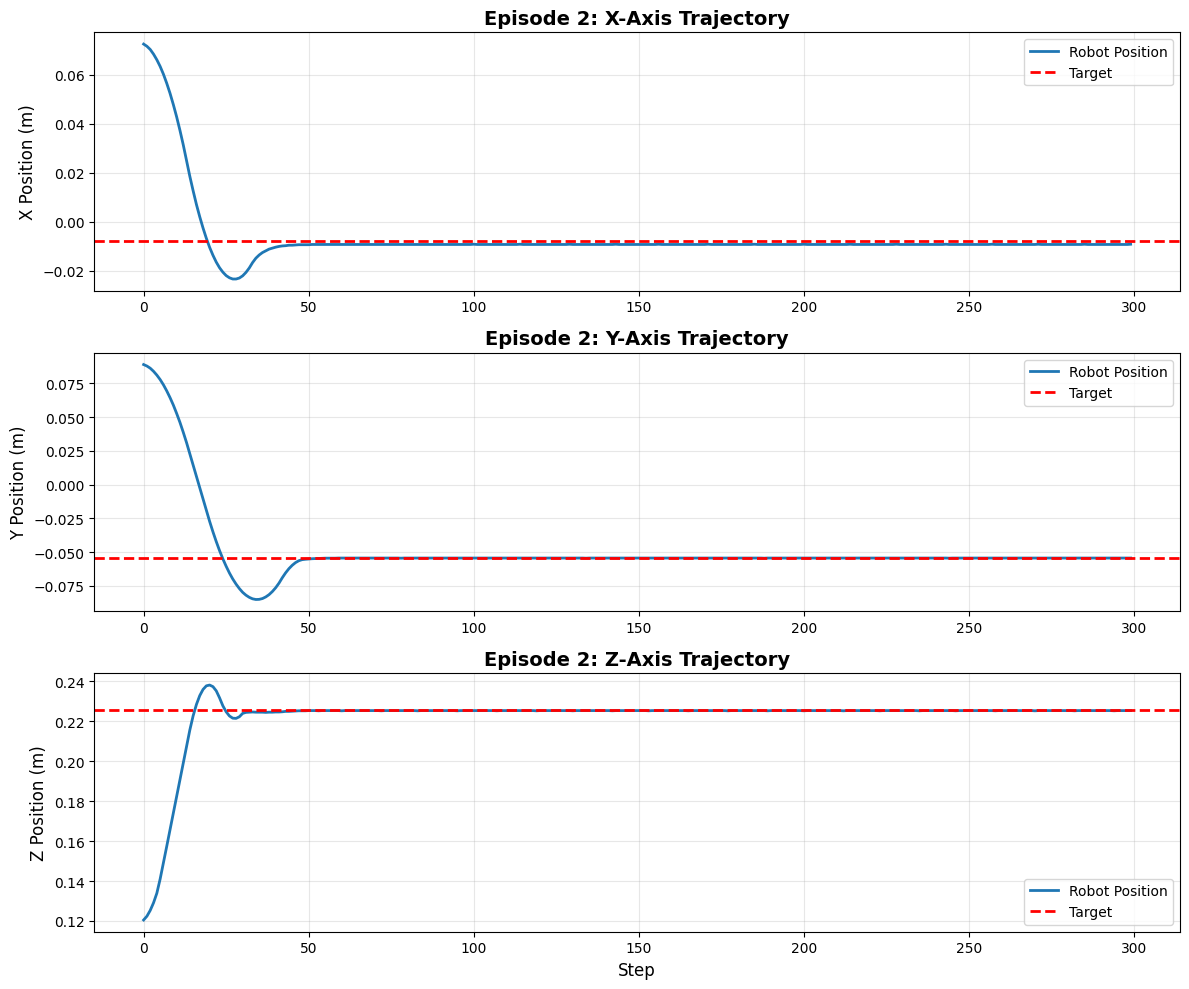

Saved: trajectory_episode_3.png


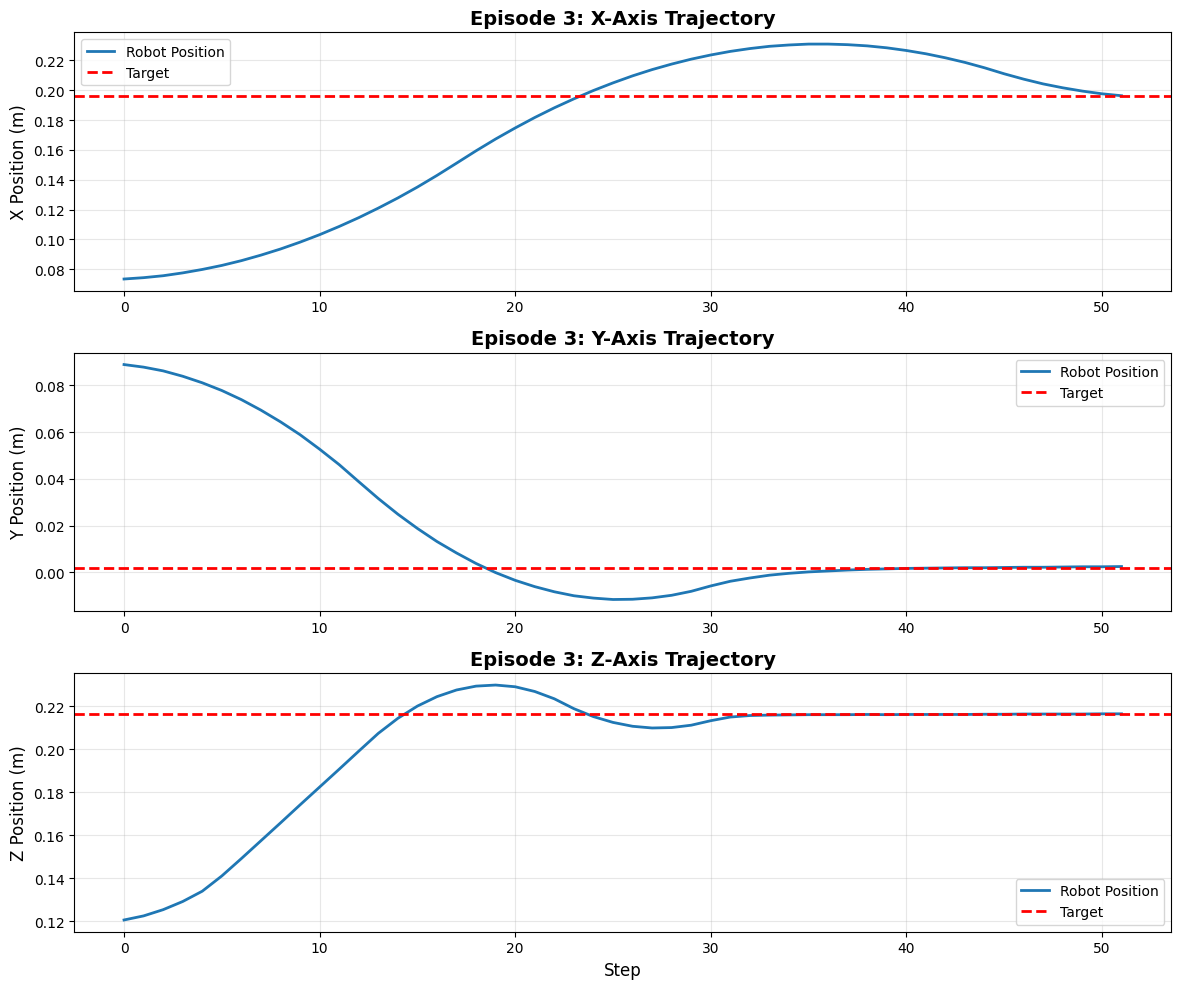

Saved: trajectory_episode_4.png


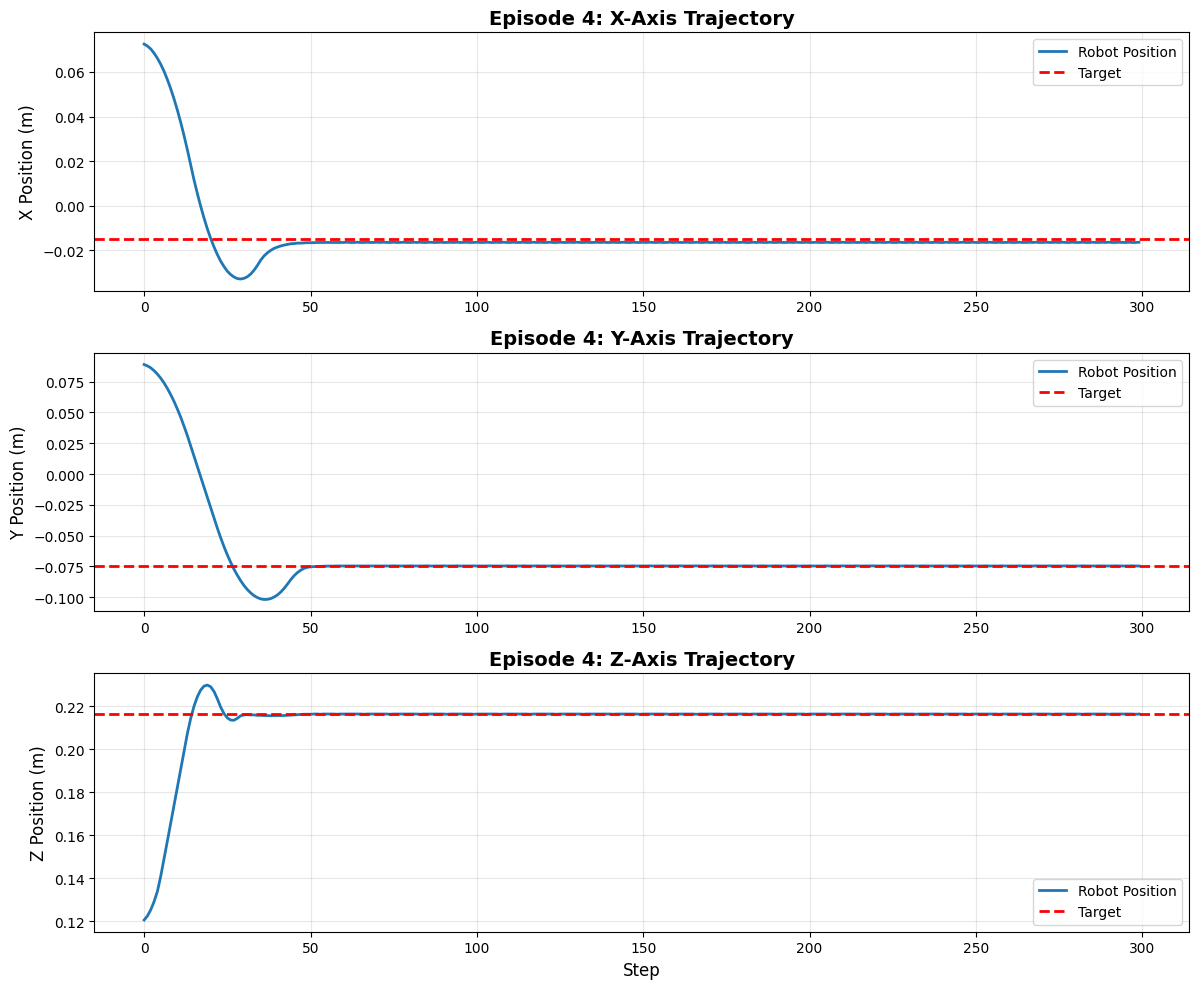

Saved: trajectory_episode_5.png


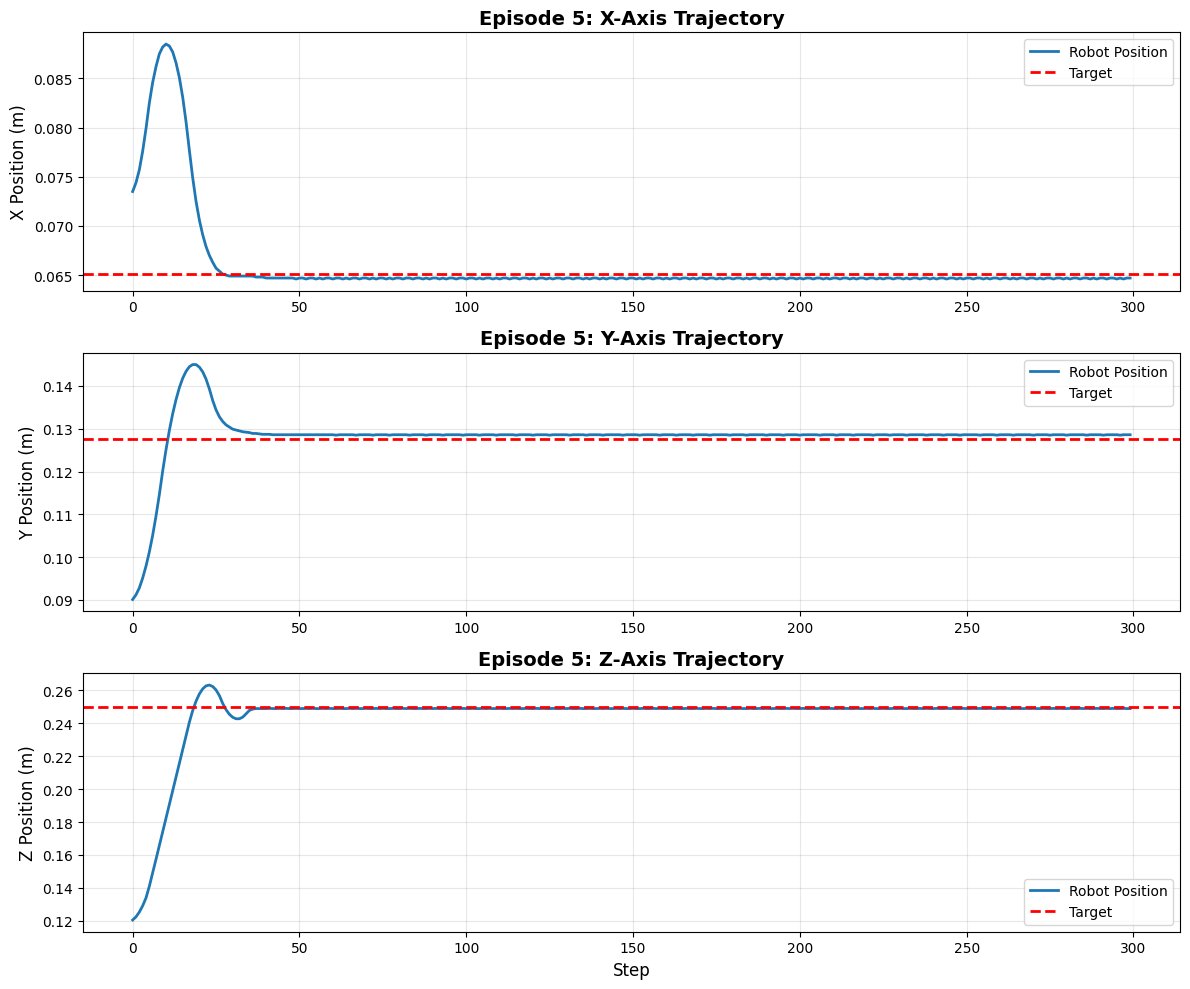


✓ All trajectory plots saved to <project>\DataLabs\Task 11\results_aaron


In [8]:
# Create output directory for saving visualizations
output_dir = task11_dir / "results", "group"
output_dir.mkdir(exist_ok=True)
print(f"Saving visualizations to: {output_dir}\n")

# Visualize trajectories for each episode
for episode_idx in range(num_episodes):
    trajectory = all_trajectories[episode_idx]
    goal = all_goals[episode_idx]
    
    fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 10))
    
    # X-axis trajectory
    ax1.plot(trajectory['x'], linewidth=2, label='Robot Position')
    ax1.axhline(y=goal[0], color='r', linestyle='--', linewidth=2, label='Target')
    ax1.set_ylabel('X Position (m)', fontsize=12)
    ax1.set_title(f'Episode {episode_idx + 1}: X-Axis Trajectory', fontsize=14, fontweight='bold')
    ax1.legend(fontsize=10)
    ax1.grid(True, alpha=0.3)
    
    # Y-axis trajectory
    ax2.plot(trajectory['y'], linewidth=2, label='Robot Position')
    ax2.axhline(y=goal[1], color='r', linestyle='--', linewidth=2, label='Target')
    ax2.set_ylabel('Y Position (m)', fontsize=12)
    ax2.set_title(f'Episode {episode_idx + 1}: Y-Axis Trajectory', fontsize=14, fontweight='bold')
    ax2.legend(fontsize=10)
    ax2.grid(True, alpha=0.3)
    
    # Z-axis trajectory
    ax3.plot(trajectory['z'], linewidth=2, label='Robot Position')
    ax3.axhline(y=goal[2], color='r', linestyle='--', linewidth=2, label='Target')
    ax3.set_xlabel('Step', fontsize=12)
    ax3.set_ylabel('Z Position (m)', fontsize=12)
    ax3.set_title(f'Episode {episode_idx + 1}: Z-Axis Trajectory', fontsize=14, fontweight='bold')
    ax3.legend(fontsize=10)
    ax3.grid(True, alpha=0.3)
    
    plt.tight_layout()
    
    # Save the figure
    save_path = output_dir / f'trajectory_episode_{episode_idx + 1}.png'
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    print(f"Saved: trajectory_episode_{episode_idx + 1}.png")
    
    plt.show()

print(f"\n✓ All trajectory plots saved to {output_dir}")

✓ Saved: distance_convergence_all_episodes.png


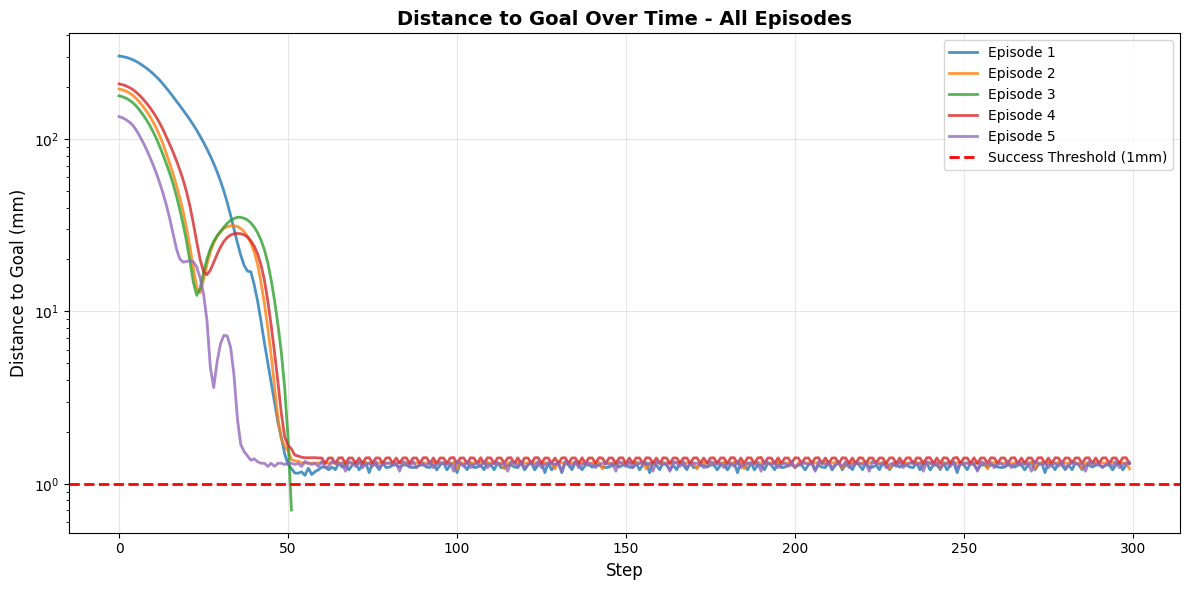

In [9]:
# Visualize distance to goal over time for all episodes
fig, ax = plt.subplots(figsize=(12, 6))

for episode_idx in range(num_episodes):
    distances_mm = [d * 1000 for d in all_distances[episode_idx]]  # Convert to mm
    ax.plot(distances_mm, linewidth=2, label=f'Episode {episode_idx + 1}', alpha=0.8)

ax.axhline(y=1.0, color='r', linestyle='--', linewidth=2, label='Success Threshold (1mm)')
ax.set_xlabel('Step', fontsize=12)
ax.set_ylabel('Distance to Goal (mm)', fontsize=12)
ax.set_title('Distance to Goal Over Time - All Episodes', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_yscale('log')  # Log scale to see convergence better

plt.tight_layout()

# Save the figure
save_path = output_dir / 'distance_convergence_all_episodes.png'
plt.savefig(save_path, dpi=150, bbox_inches='tight')
print(f"✓ Saved: distance_convergence_all_episodes.png")

plt.show()

In [10]:
# Summary statistics
print("=== Summary Statistics ===\n")

for episode_idx in range(num_episodes):
    final_distance_mm = all_distances[episode_idx][-1] * 1000
    steps_taken = len(all_distances[episode_idx])
    success = final_distance_mm < 1.0
    
    print(f"Episode {episode_idx + 1}:")
    print(f"  Steps: {steps_taken}")
    print(f"  Final distance: {final_distance_mm:.3f}mm")
    print(f"  Success: {'✓' if success else '✗'}")
    print()

# Overall statistics
success_count = sum(1 for i in range(num_episodes) if all_distances[i][-1] * 1000 < 1.0)
avg_steps = np.mean([len(d) for d in all_distances])
avg_final_distance = np.mean([d[-1] * 1000 for d in all_distances])

print(f"Overall Performance:")
print(f"  Success Rate: {success_count}/{num_episodes} ({success_count/num_episodes*100:.1f}%)")
print(f"  Average Steps: {avg_steps:.1f}")
print(f"  Average Final Distance: {avg_final_distance:.3f}mm")

=== Summary Statistics ===

Episode 1:
  Steps: 300
  Final distance: 1.325mm
  Success: ✗

Episode 2:
  Steps: 300
  Final distance: 1.219mm
  Success: ✗

Episode 3:
  Steps: 52
  Final distance: 0.704mm
  Success: ✓

Episode 4:
  Steps: 300
  Final distance: 1.311mm
  Success: ✗

Episode 5:
  Steps: 300
  Final distance: 1.315mm
  Success: ✗

Overall Performance:
  Success Rate: 1/5 (20.0%)
  Average Steps: 250.4
  Average Final Distance: 1.175mm


In [11]:
# Clean up
env.close()
print("Environment closed")

Environment closed
